In [1]:
from pynamicalsys import DiscreteDynamicalSystem as dds
from pynamicalsys import PlotStyler
from numba import njit
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds = dds(model="standard map")
ds.set_parameters(1.5)

In [3]:
u = [0.05, 0.05]
total_time = int(1e6)
warmup_time = int(1e4)
tail_time = int(1e4)

In [4]:
clvs, traj = ds.CLV(u, total_time, warmup_time=warmup_time, tail_time=tail_time)

In [5]:
angles, traj = ds.CLV_angles(u, total_time, subspaces=([0], [1]), pairs=(0, 1), warmup_time=warmup_time, tail_time=tail_time)

In [6]:
angles.shape

(1000001, 2)

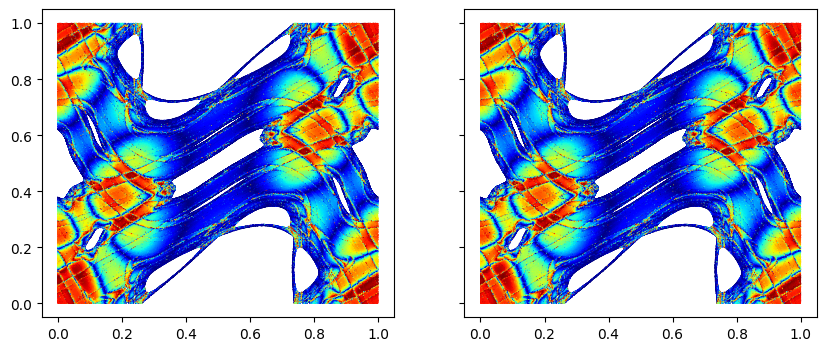

In [7]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 4))
ax[0].scatter(traj[:, 0], traj[:, 1], c=angles[:, 0], vmin=0, vmax=np.pi/2, cmap="jet", s=0.5, edgecolor="none")
ax[1].scatter(traj[:, 0], traj[:, 1], c=angles[:, 1], vmin=0, vmax=np.pi/2, cmap="jet", s=0.5, edgecolor="none")

In [8]:
@njit
def henon_map_3D(u, parameters):
    a, b, c = parameters
    x, y, z = u
    x_new = y
    y_new = z
    z_new = b * x + a * z + c * y - z**2

    return np.array([x_new, y_new, z_new])

@njit
def henon_map_3D_jacobian(u, parameters, *args):
    a, b, c = parameters
    x, y, z = u
    J = np.zeros((3, 3), dtype=np.float64)

    J[0, 0] = 0
    J[0, 1] = 1
    J[0, 2] = 0

    J[1, 0] = 0
    J[1, 1] = 0
    J[1, 2] = 1

    J[2, 0] = b
    J[2, 1] = c
    J[2, 2] = a - 2 * z

    return J

In [9]:
parameters = [-1.11, 0.7, 0.77]
ds = dds(mapping=henon_map_3D, jacobian=henon_map_3D_jacobian, system_dimension=3, parameters=parameters)

In [10]:
u = [0.05, 0.05, 0.05]
total_time = int(1e6)
warmup_time = int(1e4)
tail_time = int(1e4)
transient_time = int(1e4)
sample_size = total_time - transient_time
sample_times = np.unique(np.logspace(np.log10(1), np.log10(sample_size), 1000).astype(int))

In [11]:
lyaps = ds.lyapunov(u, total_time, transient_time=transient_time,
                    return_history=True, sample_times=sample_times)

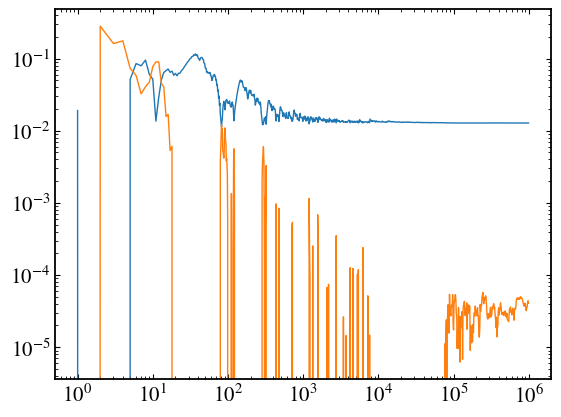

In [17]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
plt.loglog(sample_times, lyaps[:, 0])
plt.loglog(sample_times, lyaps[:, 1])

In [13]:
angles, traj = ds.CLV_angles(u, total_time, subspaces=([0, 1], [2]), pairs=(0, 2), warmup_time=warmup_time, tail_time=tail_time, transient_time=transient_time)

In [14]:
traj.shape, angles.shape

((1000001, 3), (1000001, 2))

<Figure size 640x480 with 0 Axes>

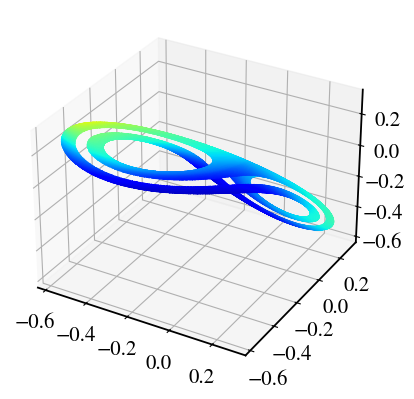

In [15]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(traj[:, 2], traj[:, 0], traj[:, 1], s=0.2, c=angles[:, 0], edgecolor="none", vmin=0, vmax=np.pi/2, cmap="jet")

<Figure size 640x480 with 0 Axes>

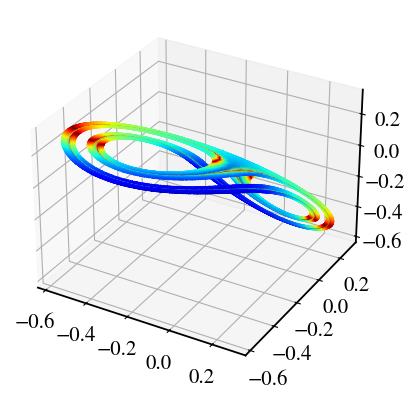

In [16]:
ps = PlotStyler(fontsize=18, markersize=0.1, markeredgewidth=0)
ps.apply_style()
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(traj[:, 2], traj[:, 0], traj[:, 1], s=0.2, c=angles[:, 1], edgecolor="none", vmin=0, vmax=np.pi/2, cmap="jet")